In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

### 1) Get SALSA latents.

In [2]:
import pandas as pd

tokens_salsa = '#%()+-0123456789<=>BCFHILNOPRSX[]cnos'
fname = 'data/model_ready/dyes/full/anchor_smiles.csv'
df = pd.read_csv(fname)
# display(df)
tokens_dyes = list(set(list(''.join(df.smiles.values))))
print(len(tokens_dyes), len(tokens_salsa))

32 37


In [3]:
from benchmark_utils import get_latents
from utilities.fp_utils import get_fps_in_parallel
import numpy as np

seedy = 666

def undo_BrCl_singles(smi):
    smi = smi.replace('R','Br')
    return smi.replace('L','Cl')
def do_BrCl_singles(smi):
    smi = smi.replace('Br','R')
    return smi.replace('Cl','L')   

# # # # # # # # # # # #
load_bs = 50
# # # # # # # # # # # #

tags = ['2022041804_04',  # salsa
        '2022041807_a03', # contrastive encoder 
        '2022041809_a04', # vanilla ae
        'morgan']         # morgan fingerprint

for tag in tags:
    
    if tag!='2022041804_04':
        continue
    
    if tag=='morgan':
        df = pd.read_csv(fname)
        smis = [undo_BrCl_singles(sm) for sm in df.smiles]
        fps = get_fps_in_parallel(smis,fp_type='morgan',counts=False,bits=1024,radius=2)
        X = np.stack(fps)
    else:
        X = get_latents(tag, ds_set='dyes', ds_cut='full', load_bs=load_bs) 

Using 4 GPUs!
Loaded model weights from /home/kat/Repos/SALSA/results/models/2022041804_04/29.pt!


28it [00:09,  3.05it/s]                        


In [5]:
fname = 'data/dye_data/hex_cansmi_salsified.csv'
df_hex = pd.read_csv(fname)
df_hex
y = df_hex.Outcome.values

In [8]:
X.shape, y.shape

((1394, 32), (1394,))

In [29]:
from sklearn.model_selection import StratifiedKFold
from utilities.fp_utils import get_fps_in_parallel
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

seedy = 666

## for holding results ... 
df_y = pd.DataFrame(y, columns=['y_test'])

skf = StratifiedKFold(n_splits=5, random_state=seedy, shuffle=True)
skf.get_n_splits(X, y)

regr = linear_model.LinearRegression()

for i,(train_idx, test_idx) in enumerate(skf.split(X,y)):
#     if i==1:
#         break
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    regr.fit(X_train,y_train)
    y_pred = regr.predict(X_test)
    df_y.loc[test_idx,'y_pred'] = y_pred

In [30]:
df_y = df_y.dropna()
df_y

,y_test,y_pred
0,698.0,498.557251
1,664.0,524.499512
2,656.0,483.378021
3,676.0,548.895264
4,654.0,555.077393
...,...,...
1389,380.0,363.120270
1390,380.0,494.192474
1391,380.0,447.342712
1392,380.0,438.312500


In [33]:
print("MAE: %.2f" % mean_absolute_error(df_y.y_test, df_y.y_pred))
print("R^2: %.2f" % r2_score(df_y.y_test, df_y.y_pred))

rmse = np.sqrt(mean_squared_error(df_y.y_test, df_y.y_pred))
print("RMSE: %.2f" % rmse)

MAE: 51.46
R^2: 0.40
RMSE: 64.70


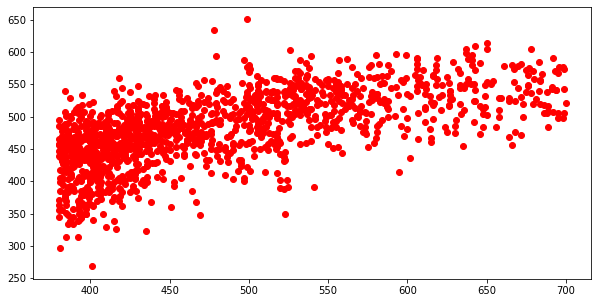

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.scatter(df_y.y_test, df_y.y_pred, color = 'red')
plt.show()